In [1]:
# =====================================
# 1. Import Libraries
# =====================================
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\Yuktha
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Yuktha
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Yuktha
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
# =====================================
# 2. Load Dataset
# =====================================
df = pd.read_csv("gender_bias_dataset.csv.gz")  # Make sure your CSV path is correct
print("Original dataset shape:", df.shape)
print(df['label'].value_counts())

Original dataset shape: (17880, 2)
label
biased      12691
unbiased     5189
Name: count, dtype: int64


In [3]:
# =====================================
# 3. Text Cleaning Function
# =====================================
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'#URL_\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [4]:
# =====================================
# 4. Remove Stopwords
# =====================================
stop_words = set(stopwords.words('english'))
df['clean_text'] = df['clean_text'].apply(
    lambda x: ' '.join([w for w in x.split() if w not in stop_words])
)

In [5]:
# =====================================
# 5. Lemmatization
# =====================================
lemmatizer = WordNetLemmatizer()
df['clean_text'] = df['clean_text'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(w) for w in x.split()])
)

In [6]:
# =====================================
# 6. Handle Imbalanced Classes
# =====================================
df_majority = df[df.label=='biased']
df_minority = df[df.label=='unbiased']

# Upsample minority class
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
print("Balanced dataset shape:", df_balanced.shape)
print(df_balanced['label'].value_counts())

Balanced dataset shape: (25382, 3)
label
biased      12691
unbiased    12691
Name: count, dtype: int64


In [7]:
# =====================================
# 7. Save Preprocessed Dataset
# =====================================

# Choose columns to keep
df_balanced_to_save = df_balanced[['clean_text', 'label']]

# Save to CSV
df_balanced_to_save.to_csv("gender_dataset_preprocessed.csv", index=False)

print("Preprocessed dataset saved as 'gender_dataset_preprocessed.csv'")

Preprocessed dataset saved as 'gender_dataset_preprocessed.csv'


#Model Implementation

In [8]:
# =====================================
# 8. Feature Extraction (TF-IDF)
# =====================================
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df_balanced['clean_text'])
y = df_balanced['label']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (25382, 5000)


In [9]:
# =====================================
# 9. Train-Test Split
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 20305
Testing samples: 5077


In [10]:
# =====================================
# 10. Model Training
# =====================================
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


Model Evaluation


In [11]:
# =====================================
# 11. Model Evaluation
# =====================================
y_pred = model.predict(X_test)
print("Predictions made successfully.")
y_pred

Predictions made successfully.


array(['unbiased', 'biased', 'unbiased', ..., 'biased', 'unbiased',
       'unbiased'], shape=(5077,), dtype=object)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
classification=classification_report(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Classification Report: {classification}")

Accuracy Score: 0.9027
Classification Report:               precision    recall  f1-score   support

      biased       0.91      0.89      0.90      2567
    unbiased       0.89      0.92      0.90      2510

    accuracy                           0.90      5077
   macro avg       0.90      0.90      0.90      5077
weighted avg       0.90      0.90      0.90      5077



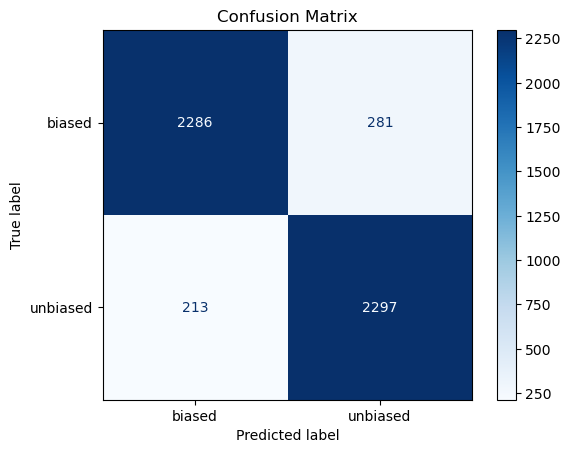

Confusion matrix generated and displayed.


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
print("Confusion matrix generated and displayed.")

In [14]:
print(f"\n--- Model Performance Summary ---\n")
print(f"The Logistic Regression model achieved an overall accuracy of {accuracy:.4f} on the test set.")
print(f"\nAccording to the Classification Report:\n")
print(classification_report(y_test, y_pred))
print(f"\nInsights from the Confusion Matrix:\n")
print(f"- True Positives (Biased correctly predicted): {cm[0,0]}")
print(f"- False Positives (Unbiased incorrectly predicted as Biased): {cm[0,1]}")
print(f"- False Negatives (Biased incorrectly predicted as Unbiased): {cm[1,0]}")
print(f"- True Negatives (Unbiased correctly predicted): {cm[1,1]}")
print(f"\nThe model shows good balance between precision and recall for both 'biased' and 'unbiased' classes, with f1-scores around 0.90 for both. The confusion matrix further indicates a relatively low number of misclassifications, suggesting the model is effective in distinguishing between gender-biased and unbiased text.")


--- Model Performance Summary ---

The Logistic Regression model achieved an overall accuracy of 0.9027 on the test set.

According to the Classification Report:

              precision    recall  f1-score   support

      biased       0.91      0.89      0.90      2567
    unbiased       0.89      0.92      0.90      2510

    accuracy                           0.90      5077
   macro avg       0.90      0.90      0.90      5077
weighted avg       0.90      0.90      0.90      5077


Insights from the Confusion Matrix:

- True Positives (Biased correctly predicted): 2286
- False Positives (Unbiased incorrectly predicted as Biased): 281
- False Negatives (Biased incorrectly predicted as Unbiased): 213
- True Negatives (Unbiased correctly predicted): 2297

The model shows good balance between precision and recall for both 'biased' and 'unbiased' classes, with f1-scores around 0.90 for both. The confusion matrix further indicates a relatively low number of misclassifications, suggestin

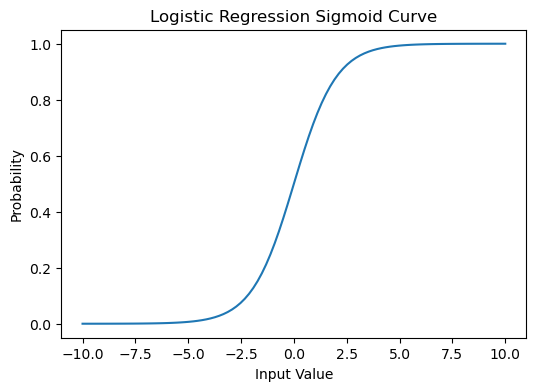

In [ ]:
#=====================================
# Visualisation and Graphs
#=====================================

# Logistic Regression Sigmoid Curve

import numpy as np
import matplotlib.pyplot as plt

# Generate values
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(6,4))
plt.plot(x, y)

plt.title("Logistic Regression Sigmoid Curve")
plt.xlabel("Input Value")
plt.ylabel("Probability")

plt.show()

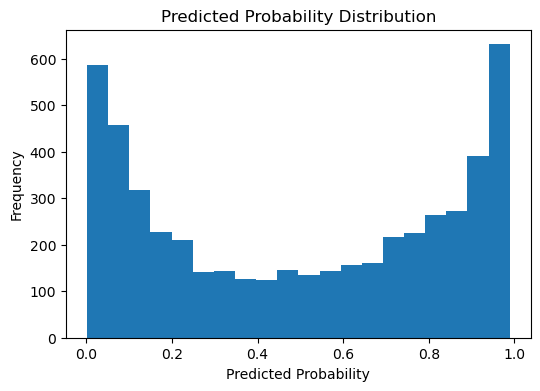

In [ ]:
# Predicted Probability Distribution

y_prob = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,4))
plt.hist(y_prob, bins=20)

plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")

plt.show()

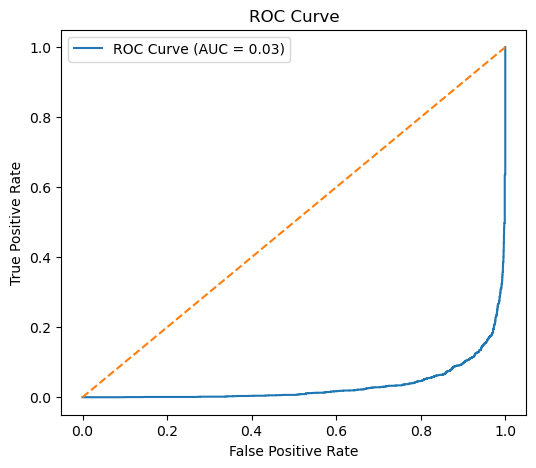

In [ ]:
# ROC Curve and AUC

from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='biased')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

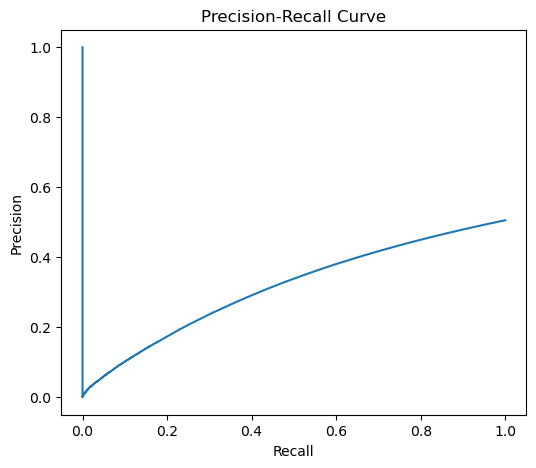

In [ ]:
# Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob, pos_label='biased')

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()